# Détection précoce du décrochage étudiant en L1

## Dossier de certification — « Concevoir et implémenter une solution d'intelligence artificielle »

| | |
|---|---|
| **Intitulé du projet** | Détection précoce des étudiants en risque de décrochage en L1 |
| **Type de problème** | Apprentissage supervisé — classification binaire (`abandon`) + régression secondaire (`moyenne_finale`) |
| **Candidat** | *Staudt Michael* |
| **Parcours** | Data Scientist |
| **Date / Version** | *jj/mm/2026* — v1.0 |
| **Environnement d'exécution** | Python 3.13 · `uv` · scikit-learn, XGBoost, SHAP · exécuté sous Jupyter |
| **Compétences couvertes** | Référentiel complet C1 → C9 |

> **Comment lire ce notebook.** Il est **exécutable de bout en bout** et **lisible sans explication orale**. Chaque grande étape se termine par un **journal de bord** (encadré *JdB*) qui explicite les décisions prises et leur justification. Les fonctions déterministes de nettoyage et de scoring sont isolées dans le package `src/decrochage/` (reproductibilité, compétence C6) ; le notebook les importe et documente la démarche.

## 1. Résumé exécutif

**Problème métier.** Une université pluridisciplinaire observe un taux d'abandon élevé en L1 (~28 % dans les données). La direction de la réussite étudiante veut **détecter dès le milieu du S1** les étudiants à risque pour déclencher un accompagnement (tutorat, soutien méthodologique, aide sociale).

**Objectif IA.** Estimer, à mi-parcours du S1, la **probabilité de décrochage** de chaque étudiant (`abandon`, classification binaire) et, en cible secondaire, sa **moyenne finale attendue** (`moyenne_finale`, régression) pour calibrer l'intensité de l'accompagnement.

**Approche.** Nettoyage rigoureux de données volontairement « brutes » (doublons, nombres en texte, dates multi-formats, encodages incohérents), **exclusion stricte des fuites** (cible secondaire, identifiants, résultats consolidés de fin de S1) et des **3 leurres**, enrichissement par le catalogue des formations, puis comparaison d'une baseline et de trois familles de modèles, évaluées par la **courbe ROC / AUC**.

**Résultats clés** *(calculés dans ce notebook)*.

| Élément | Valeur |
|---|---|
| Modèle retenu | Régression logistique (régularisée, pondérée) |
| AUC (test) | ≈ **0,95** |
| Rappel des décrocheurs au seuil métier | ≈ **0,90** |
| Facteurs de risque dominants | taux de présence, heures LMS, motivation, taux de rendu, retards |
| Régression `moyenne_finale` | R² ≈ 0,68 · MAE ≈ 2,3 pts |

**Limites principales.** Données synthétiques (validité externe à confirmer par A/B test) ; variables sensibles à surveiller (sexe, boursier, origine) ; le score est un **outil d'aide à la priorisation**, pas une décision automatique sur l'étudiant.

### Environnement et fonctions utilitaires

On importe les dépendances et le package projet `decrochage` (installé via `uv`), qui porte le code de nettoyage/scoring réutilisable. Les chemins sont résolus relativement à la racine du projet pour que le notebook s'exécute quel que soit le dossier de lancement.

In [1]:
import platform
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 110

# Racine du projet (le notebook vit dans notebooks/)
CWD = Path.cwd()
ROOT = CWD.parent if CWD.name == "notebooks" else CWD
DATA = ROOT / "data" / "raw"
FIG = ROOT / "artifacts" / "figures"
MODELS = ROOT / "artifacts" / "models"
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
FIG.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

# Package projet (nettoyage, périmètre de scoring, serving)
from decrochage import preprocessing as pp, features as F  # noqa: E402
from decrochage import serving  # noqa: E402

RANDOM_STATE = 42
N_JOBS = 1  # exécution stable sous Windows/Jupyter, sans tracebacks joblib/loky
print("Python", platform.python_version(), "| pandas", pd.__version__)
print("Racine projet :", ROOT)

Python 3.13.13 | pandas 2.3.3
Racine projet : C:\Projects\aelion\examen


## 2. Cadrage métier et cas d'usage — journal de bord *(C1)*

### 2.1 Reformulation du besoin

La **direction de la réussite étudiante** doit décider, à mi-S1, **quels étudiants accompagner en priorité** avec des ressources limitées (tuteurs, créneaux de soutien, aides). Aujourd'hui cette décision repose sur le repérage tardif (souvent après les partiels), quand le décrochage est déjà engagé.

- **Problématique métier** : *identifier suffisamment tôt les étudiants à risque pour agir avant l'abandon, sans stigmatiser ni sur-solliciter.*
- **Problématique IA** : *apprendre un modèle de classification qui estime, à partir des seules données disponibles à mi-S1, la probabilité de décrochage — restituée comme un score explicable.*

### 2.2 Deux cibles, deux usages

| Cible | Type | Usage métier |
|---|---|---|
| `abandon` (0/1) | Classification (principale) | Déclencher / prioriser l'accompagnement (analyse ROC/AUC) |
| `moyenne_finale` (/20) | Régression (secondaire) | Calibrer l'intensité de l'aide (soutien léger vs renforcé) |

### 2.3 Variables pertinentes vs leurres *(justification C1)*

- **Signaux attendus** (disponibles à mi-S1) : engagement (présence, LMS, ressources, forum), assiduité aux rendus (taux de rendu, retards), ressenti (motivation, satisfaction, appartenance), contexte socio-scolaire (bac, mention, boursier, distance, travail rémunéré), filière.
- **Leurres identifiés et écartés** : `groupe_td`, `couleur_carte_etudiante`, `jour_inscription` — aucun lien causal plausible avec le décrochage ; conservés uniquement pour **vérifier** l'absence de signal (section EDA) puis exclus.
- **Enrichissement** : jointure du **catalogue des formations** (`catalogue_formations_V5.csv`) via `filiere` pour ajouter faculté, ECTS, capacité, volume horaire, **taux de réussite historique** de la filière.

*Alternative en cas de données manquantes* : à défaut du catalogue, on pourrait dériver un taux de réussite par filière depuis l'historique interne ; à défaut des signaux LMS, se rabattre sur l'assiduité déclarée en TD.

## 3. Données : disponibilité, gouvernance et alternatives — journal de bord *(C1)*

### 3.1 Sources et disponibilité

| Source | Contenu | Fréquence | Accès |
|---|---|---|---|
| SI Scolarité | État civil, filière, bac, bourse, inscription | Annuelle | Extraction sécurisée |
| LMS (Moodle…) | Connexions, heures, ressources, forum, rendus | Quotidienne | API / export |
| Suivi pédagogique | Motivation/satisfaction/appartenance (questionnaire), commentaire tuteur | Ponctuelle | Base de suivi |
| Catalogue formations | Référentiel filières (ECTS, capacité, taux de réussite) | Annuelle | Table de référence |

### 3.2 Gouvernance et cycle de vie *(C3)*

- **Minimisation** : seules les variables utiles au repérage sont mobilisées ; les identifiants directs sont exclus du modèle.
- **Traçabilité** : le nettoyage est **versionné dans le code** (`src/decrochage/preprocessing.py`) → reproductible et auditable.
- **Rétention** : les scores de risque sont des données sensibles (voir §4) → durée de conservation limitée à l'année universitaire, purge ensuite.
- **Cycle** : données brutes (`data/raw/`, immuables) → données nettoyées (`data/processed/`, régénérables) → modèle (`artifacts/models/`).

*JdB.* Les données fournies sont **synthétiques et volontairement imparfaites**. Décision : les traiter comme un flux réel (nettoyage documenté), et signaler explicitement que toute conclusion de performance devra être **revalidée sur données réelles** avant déploiement.

## 4. Enjeux éthiques, sociétaux et conformité — journal de bord *(C2)*

### 4.1 Variables sensibles et risques de biais

`sexe`, `boursier`, `etablissement_origine` (proxy socio-économique) sont des **variables sensibles**. Risques :

- **Biais de représentation** : un groupe sous-représenté peut être moins bien prédit.
- **Biais indirect** : même en retirant `sexe`, des variables corrélées peuvent réintroduire une discrimination.
- **Effet de « marquage »** : étiqueter un étudiant « à risque » peut créer une prophétie auto-réalisatrice ou un stigmate.

### 4.2 Conformité RGPD (données scolaires)

- **Base légale / finalité** : intérêt légitime d'accompagnement pédagogique, finalité **explicite et limitée** (aide, pas sanction).
- **Information des parties prenantes** : étudiants informés de l'existence du dispositif et de leurs droits (accès, rectification, opposition).
- **Décision humaine** : le score **n'automatise aucune décision** ; il alimente une équipe pédagogique qui garde la main (pas de décision individuelle entièrement automatisée — art. 22 RGPD).

### 4.3 Garde-fous retenus

1. **Explicabilité** : modèle et facteurs de risque lisibles (coefficients + importance des variables + SHAP).
2. **Analyse par sous-groupes** : mesurer performance et taux d'alerte par `sexe` / `boursier` (section 12) pour détecter un traitement inéquitable.
3. **Usage encadré** : le score sert à **proposer** un accompagnement, jamais à orienter/exclure.
4. **Sobriété** : minimisation des données, modèle léger (éco-conception, C4).

*JdB.* Décision : conserver `sexe` et `boursier` **dans l'analyse exploratoire et l'audit d'équité**, mais documenter le risque ; discuter en §12 l'option d'un entraînement « fairness-aware » si un écart de traitement est constaté.

## 5. Chargement et compréhension des données *(C3)*

On charge le jeu principal et le catalogue. Le fichier est encodé en UTF-8 avec BOM (`utf-8-sig`).

In [2]:
df_raw = pd.read_csv(DATA / "decrochage_etudiants_complet_V5.csv", encoding="utf-8-sig")
catalogue = pd.read_csv(DATA / "catalogue_formations_V5.csv", encoding="utf-8-sig")

print("Jeu principal :", df_raw.shape, "| Catalogue :", catalogue.shape)
df_raw.head(3)

Jeu principal : (5240, 33) | Catalogue : (8, 7)


,student_id,annee_universitaire,filiere,age,sexe,bac_type,mention_bac,etablissement_origine,boursier,distance_domicile_km,heures_travail_remunere_sem,taux_presence_pct,connexions_lms_30j,heures_lms_total,ressources_consultees,retards_rendus,nb_devoirs_total,nb_devoirs_rendus,messages_forum,moyenne_partiels_s1,nb_ue_total,nb_ue_validees_s1,motivation,satisfaction,sentiment_appartenance,groupe_td,couleur_carte_etudiante,jour_inscription,id_dossier,date_inscription,moyenne_finale,abandon,commentaire_tuteur
0,ETU-03041,2024-2025,droit,22,NB,TECHNO,AB,lycee_public,Oui,"2,2",0.0,"86,3",33.0,35.4,73,2,12,11,4,"10,17",6,5,NaN,3.0,NaN,D,jaune,mercredi,265469,04 Sep 2024,15.06,0,RAS.
1,ETU-03916,2024-2025,Lettres,19,femme,general,passable,lycee_public,N,18.8,9.0,77.5%,45.0,56.7,114,3,13,10,7,NaN,5,4,3.0,5.0,3.0,C,bleu,vendredi,800111,2024-09-27,15.61,0,NaN
2,ETU-05174,2024-2025,Lettres,17,h,general,ab,lycee_public,Non,"42,8",0.0,"74,6",37.0,77.1,77,4,9,6,4,10.17,5,4,2.0,3.0,1.0,A,bleu,jeudi,982786,26/09/2024,14.85,0,"Motivation en berne, à accompagner."


### 5.1 Aperçu de la qualité — les imperfections annoncées

On confirme concrètement les pièges du dataset avant de les traiter : doublons, nombres stockés en texte, encodages catégoriels incohérents, dates multi-formats, valeurs manquantes.

In [3]:
print("Doublons exacts        :", df_raw.duplicated().sum())
print("Taux d'abandon (cible) : {:.1%}".format(df_raw["abandon"].mean()))
print()
for c in ["distance_domicile_km", "taux_presence_pct", "boursier", "sexe",
          "bac_type", "mention_bac", "date_inscription"]:
    ex = df_raw[c].dropna().astype(str).unique()[:6]
    print(f"{c:28s} -> {list(ex)}")

Doublons exacts        : 40
Taux d'abandon (cible) : 28.4%

distance_domicile_km         -> ['2,2', '18.8', '42,8', '12.0 km', '8,2', '31,1']
taux_presence_pct            -> ['86,3', '77.5%', '74,6', '68,2', '62.1%', '63.4']
boursier                     -> ['Oui', 'N', 'Non', 'O', 'non', '0']
sexe                         -> ['NB', 'femme', 'h', 'f', 'Homme', 'F']
bac_type                     -> ['TECHNO', 'general', 'GEN', 'techno', 'Generale', 'général ']
mention_bac                  -> ['AB', 'passable', 'ab', 'B', 'Bien', 'Passable']
date_inscription             -> ['04 Sep 2024', '2024-09-27', '26/09/2024', '19/09/2024', '04/09/2024', '19 Sep 2024']


In [4]:
# Taux de valeurs manquantes par variable (les plus touchées)
na = (df_raw.isna().mean() * 100).round(1)
na[na > 0].sort_values(ascending=False).to_frame("% manquant")

,% manquant
commentaire_tuteur,49.3
heures_travail_remunere_sem,11.9
satisfaction,8.0
sentiment_appartenance,7.0
distance_domicile_km,6.0
etablissement_origine,5.0
motivation,5.0
mention_bac,4.0
connexions_lms_30j,4.0
moyenne_partiels_s1,3.0


*Lecture.* On retrouve exactement les défauts de l'énoncé : ~40 doublons, `distance_domicile_km` avec unités/virgules (« 14.4 km », « 22,6 »), `taux_presence_pct` avec « % » et virgules, `boursier`/`sexe`/`bac_type`/`mention_bac` à encodages multiples, `date_inscription` en 3 formats, et 9 variables avec valeurs manquantes (jusqu'à ~12 %). Le `commentaire_tuteur` est vide dans ~49 % des cas.

## 6. Analyse exploratoire (EDA) : visualisations et interprétation — journal de bord *(C3)*

Pour l'EDA, on applique le **nettoyage** (parsing, normalisation, dédoublonnage) et la **jointure catalogue** afin d'analyser des variables exploitables. Le nettoyage est encapsulé dans `decrochage.preprocessing.clean_raw` (reproductible).

In [5]:
df = pp.clean_raw(df_raw)                       # dédoublonnage + parsing + normalisation
df = F.enrich_with_catalogue(df, catalogue)     # jointure catalogue via filiere
df = F.add_engineered_features(df)              # features métier disponibles à mi-S1

print("Après nettoyage :", df.shape, "| doublons retirés :", df_raw.shape[0] - df.shape[0])
print("Filières appariées au catalogue :", df["faculte"].notna().mean() * 100, "%")

Après nettoyage : (5200, 45) | doublons retirés : 40
Filières appariées au catalogue : 100.0 %


### 6.1 Distribution de la cible

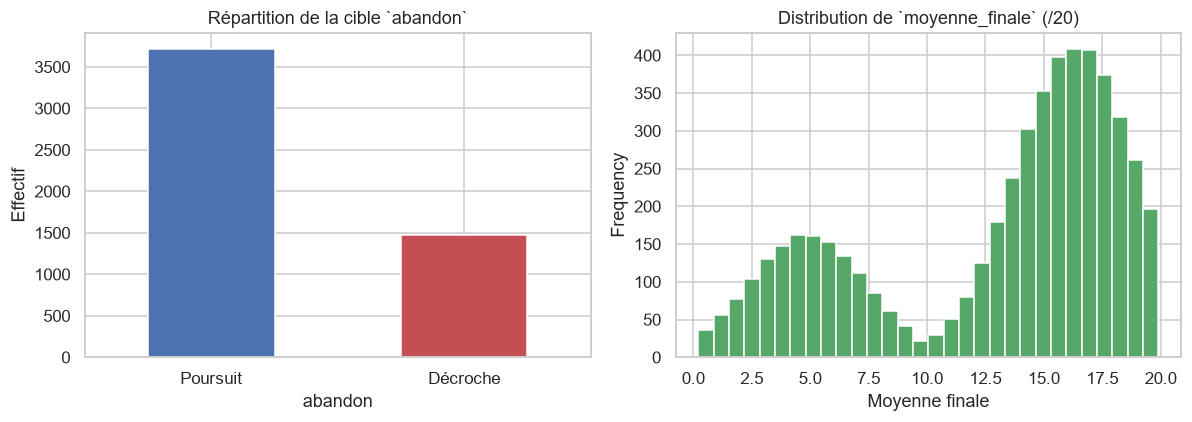

Taux d'abandon : 28.4% (léger déséquilibre)


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df["abandon"].map({0: "Poursuit", 1: "Décroche"}).value_counts().plot(
    kind="bar", ax=ax[0], color=["#4C72B0", "#C44E52"])
ax[0].set_title("Répartition de la cible `abandon`")
ax[0].set_ylabel("Effectif")
ax[0].tick_params(axis="x", rotation=0)
df["moyenne_finale"].plot(kind="hist", bins=30, ax=ax[1], color="#55A868")
ax[1].set_title("Distribution de `moyenne_finale` (/20)")
ax[1].set_xlabel("Moyenne finale")
plt.tight_layout()
plt.savefig(FIG / "eda_cible.png", bbox_inches="tight")
plt.show()
print("Taux d'abandon : {:.1%} (léger déséquilibre)".format(df["abandon"].mean()))

### 6.2 Facteurs de risque — variables numériques

On compare la distribution des principaux signaux d'engagement selon que l'étudiant décroche ou non.

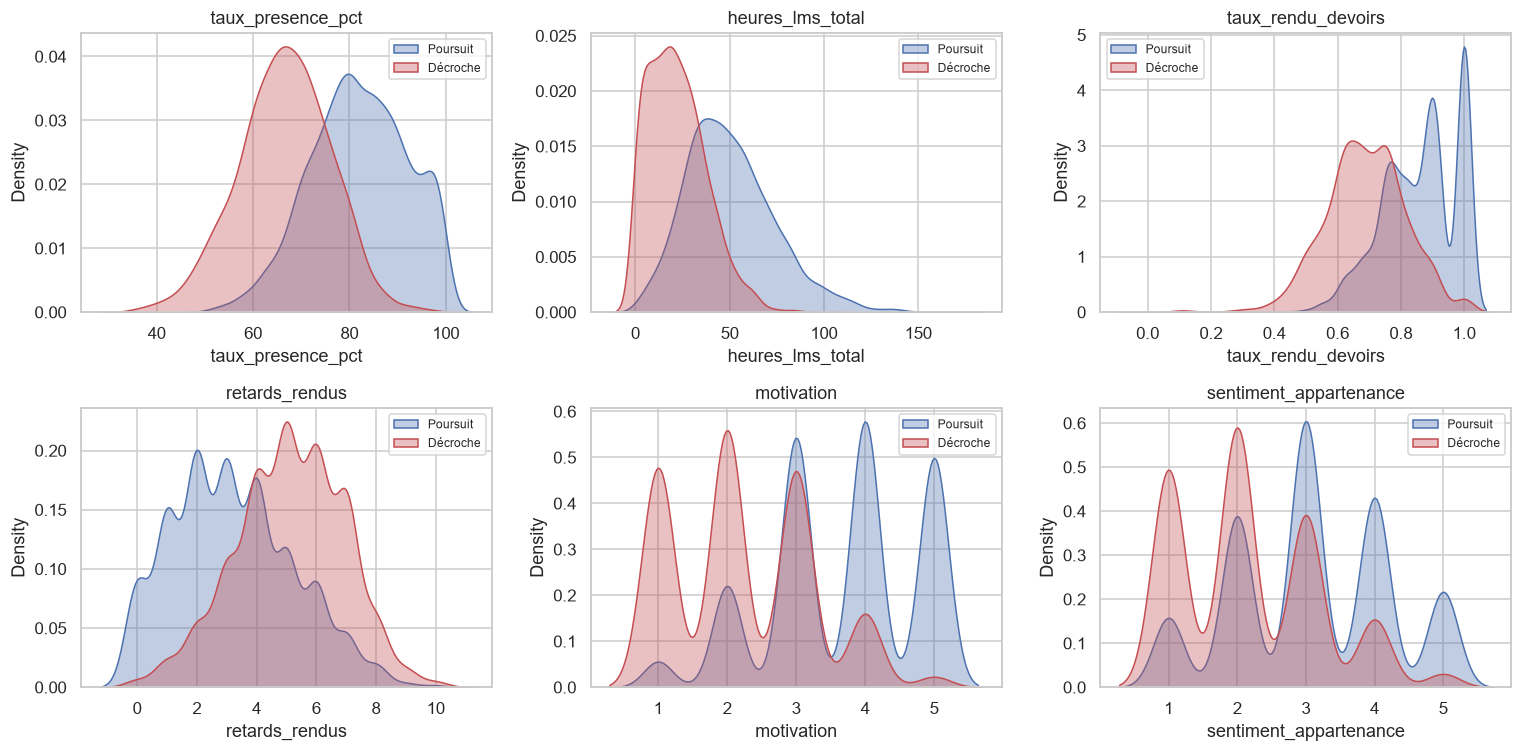

In [7]:
signaux = ["taux_presence_pct", "heures_lms_total", "taux_rendu_devoirs",
           "retards_rendus", "motivation", "sentiment_appartenance"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), signaux):
    for val, lab, c in [(0, "Poursuit", "#4C72B0"), (1, "Décroche", "#C44E52")]:
        sns.kdeplot(df.loc[df["abandon"] == val, col].dropna(), ax=ax, label=lab,
                    fill=True, alpha=0.35, color=c)
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "eda_signaux.png", bbox_inches="tight")
plt.show()

*Lecture.* Les décrocheurs présentent nettement **moins de présence**, **moins d'heures LMS**, un **taux de rendu plus bas**, **plus de retards** et une **motivation / appartenance plus faibles** — cohérent avec la littérature sur le décrochage. Ces variables, toutes disponibles à mi-S1, seront les prédicteurs centraux.

### 6.3 Taux d'abandon par variables catégorielles

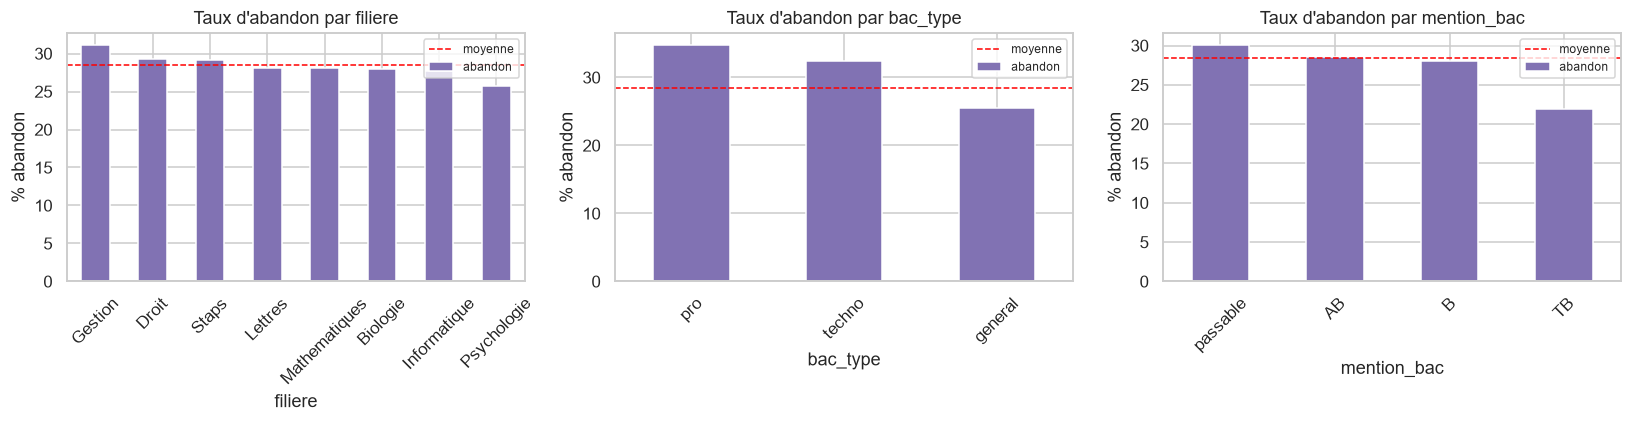

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["filiere", "bac_type", "mention_bac"]):
    (df.groupby(col)["abandon"].mean().sort_values(ascending=False) * 100).plot(
        kind="bar", ax=ax, color="#8172B3")
    ax.set_title(f"Taux d'abandon par {col}")
    ax.set_ylabel("% abandon")
    ax.axhline(df["abandon"].mean() * 100, color="red", ls="--", lw=1, label="moyenne")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "eda_categorielles.png", bbox_inches="tight")
plt.show()

### 6.4 Vérification des leurres *(rigueur méthodologique, C1)*

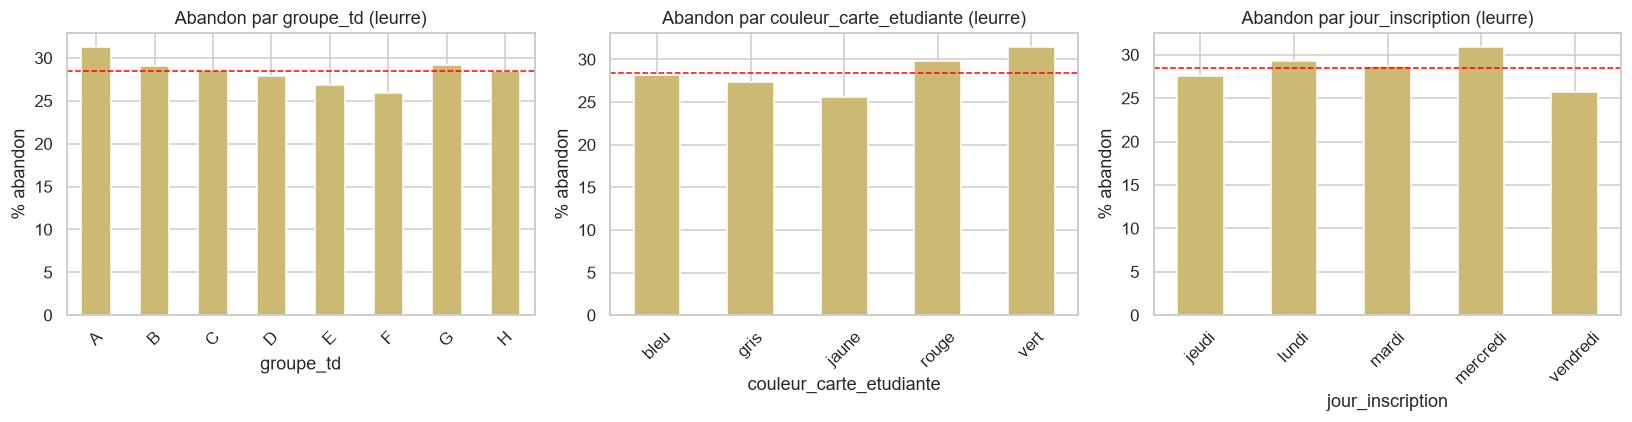

groupe_td                : écart-type du taux d'abandon entre modalités = 1.64 pts
couleur_carte_etudiante  : écart-type du taux d'abandon entre modalités = 2.26 pts
jour_inscription         : écart-type du taux d'abandon entre modalités = 1.97 pts


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, F.LEURRE_COLS):
    (df.groupby(col)["abandon"].mean() * 100).plot(kind="bar", ax=ax, color="#CCB974")
    ax.axhline(df["abandon"].mean() * 100, color="red", ls="--", lw=1)
    ax.set_title(f"Abandon par {col} (leurre)")
    ax.set_ylabel("% abandon")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIG / "eda_leurres.png", bbox_inches="tight")
plt.show()

# Écart-type du taux d'abandon entre modalités : faible => pas de signal
for col in F.LEURRE_COLS:
    ecart = df.groupby(col)["abandon"].mean().std() * 100
    print(f"{col:24s} : écart-type du taux d'abandon entre modalités = {ecart:.2f} pts")

*Lecture.* Le taux d'abandon reste **plat autour de la moyenne** quelle que soit la modalité des trois leurres (écart-type faible) : **aucun pouvoir prédictif réel**. Ils sont donc exclus du périmètre de scoring (voir §7).

### 6.5 Corrélations entre variables numériques

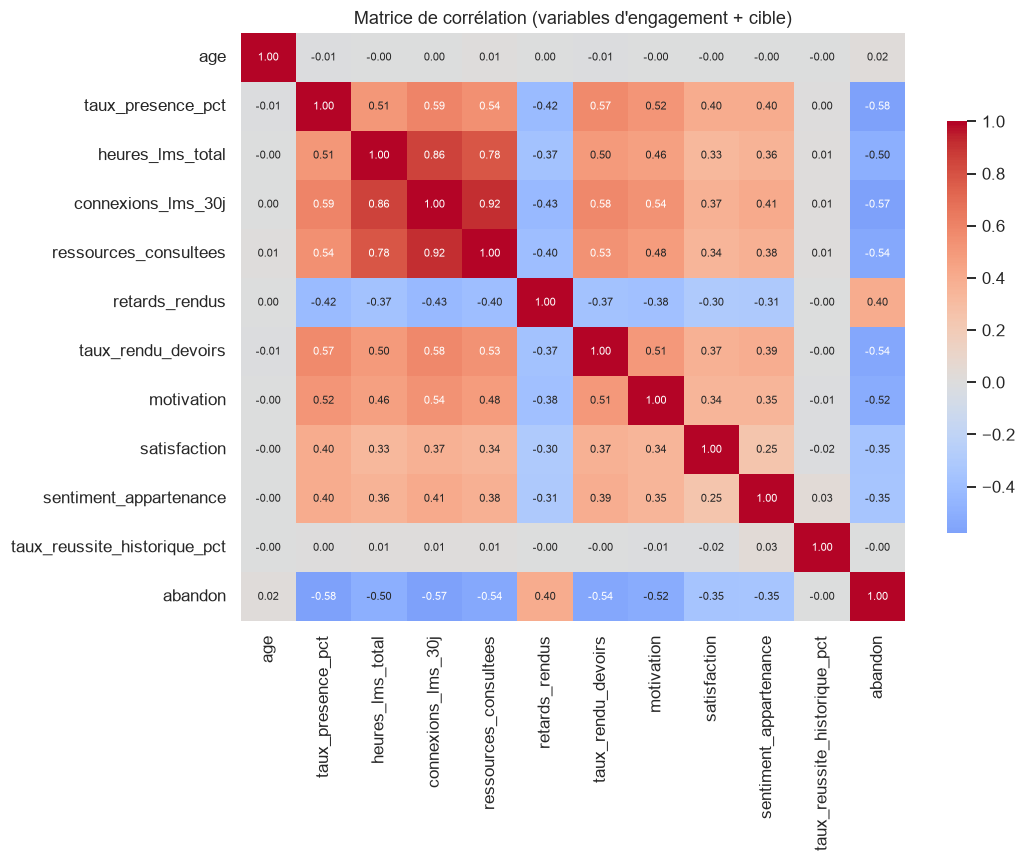

In [10]:
num_eda = ["age", "taux_presence_pct", "heures_lms_total", "connexions_lms_30j",
           "ressources_consultees", "retards_rendus", "taux_rendu_devoirs",
           "motivation", "satisfaction", "sentiment_appartenance",
           "taux_reussite_historique_pct", "abandon"]
corr = df[num_eda].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.7})
plt.title("Matrice de corrélation (variables d'engagement + cible)")
plt.tight_layout()
plt.savefig(FIG / "eda_corr.png", bbox_inches="tight")
plt.show()

*JdB — synthèse EDA.* (1) Cible déséquilibrée à ~28 % → gérer le déséquilibre (pondération) et évaluer par ROC/AUC + rappel, pas par l'accuracy. (2) Les signaux d'engagement/assiduité sont les corrélats les plus forts du décrochage. (3) Les 3 leurres sont confirmés sans signal. (4) La `moyenne_finale` est très corrélée à `abandon` (structurellement) → **fuite** à exclure des features. Décision : figer le périmètre de scoring anti-fuite avant toute modélisation.

## 7. Préparation des données (nettoyage, manquants, transformations, features) — journal de bord *(C3)*

### 7.1 Ce que fait `clean_raw` (déjà appliqué en §6)

| Étape | Traitement | Colonnes concernées |
|---|---|---|
| Dédoublonnage | `drop_duplicates` exact | toutes (40 lignes) |
| Nombres en texte | `%`, virgule FR, « km » → float | `distance_domicile_km`, `taux_presence_pct` |
| Dates multi-formats | parsing tolérant → `date_inscription_parsed` | `date_inscription` |
| Normalisation catégorielle | casse/espaces/synonymes → modalités canoniques | `filiere`, `sexe`, `bac_type`, `mention_bac`, `boursier`, `etablissement_origine` |

### 7.2 Feature engineering *(disponible à mi-S1, sans fuite)*

- `taux_rendu_devoirs` = rendus / attendus (assiduité) ;
- `heures_lms_par_connexion`, `ressources_par_connexion` (intensité d'usage) ;
- `commentaire_present` (le tuteur a-t-il signalé quelque chose) ;
- `jours_inscription` (précocité d'inscription, dérivée de la date parsée).

### 7.3 Périmètre de scoring anti-fuite — **verrou méthodologique central**

On exclut explicitement des variables explicatives :

- **Fuite de données** : `moyenne_finale` (cible secondaire, résultat de fin de semestre) ;
- **Fuite temporelle** : `moyenne_partiels_s1`, `nb_ue_validees_s1` (consolidées en fin de S1, indisponibles à mi-S1) ;
- **Identifiants** : `student_id`, `id_dossier` ; **constantes** : `annee_universitaire`, `niveau` ;
- **Leurres** : `groupe_td`, `couleur_carte_etudiante`, `jour_inscription` ;
- **Texte libre brut** : `commentaire_tuteur` (remplacé par `commentaire_present`).

Ce périmètre est **codé** dans `features.scoring_feature_columns` et **vérifié** par `features.assert_no_leakage` (garde-fou qui lève une erreur si une colonne interdite se glisse dans les features).

In [11]:
feature_cols = F.scoring_feature_columns(df)
F.assert_no_leakage(feature_cols)   # lève une AssertionError en cas de fuite

X = df[feature_cols].copy()
y_clf = df[F.TARGET_CLF].astype(int).values
y_reg = df[F.TARGET_REG].values

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(include="object").columns.tolist()

print(f"Features de scoring : {len(feature_cols)}  ({len(num_cols)} num + {len(cat_cols)} cat)")
print("\nExclues pour fuite / leurre / id :")
for grp, cols in [("Fuite données", F.LEAKAGE_TARGET_COLS),
                  ("Fuite temporelle", F.LEAKAGE_TEMPORAL_COLS),
                  ("Identifiants", F.ID_COLS), ("Leurres", F.LEURRE_COLS)]:
    print(f"  - {grp:18s}: {cols}")
print("\n[OK] Aucune colonne interdite dans les features (garde-fou passé).")

Features de scoring : 31  (25 num + 6 cat)

Exclues pour fuite / leurre / id :
  - Fuite données     : ['moyenne_finale']
  - Fuite temporelle  : ['moyenne_partiels_s1', 'nb_ue_validees_s1']
  - Identifiants      : ['student_id', 'id_dossier']
  - Leurres           : ['groupe_td', 'couleur_carte_etudiante', 'jour_inscription']

[OK] Aucune colonne interdite dans les features (garde-fou passé).


### 7.4 Stratégie d'imputation et d'encodage *(sans fuite)*

L'imputation et l'encodage sont **appris dans la Pipeline sklearn** (donc **fit sur le train uniquement**, `transform` sur le test) pour éviter toute fuite d'information du test vers l'entraînement :

- numériques → imputation **médiane** + standardisation ;
- catégorielles → imputation **mode** + one-hot (`handle_unknown="ignore"`).

On sauvegarde aussi le jeu nettoyé (`data/processed/`) comme livrable intermédiaire.

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocess = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])

(ROOT / "data" / "processed").mkdir(parents=True, exist_ok=True)
df.to_csv(ROOT / "data" / "processed" / "decrochage_clean.csv", index=False)
print("Jeu nettoyé sauvegardé -> data/processed/decrochage_clean.csv", df.shape)

Jeu nettoyé sauvegardé -> data/processed/decrochage_clean.csv (5200, 45)


## 8. Choix du modèle et démarche scientifique — journal de bord *(C4)*

### 8.1 Démarche

1. **Baseline** naïve (`DummyClassifier`) pour fixer le plancher (AUC ≈ 0,5).
2. **Trois familles** comparées sur la même Pipeline de pré-traitement :
   - **Régression logistique** (linéaire, très explicable, éco-sobre) ;
   - **Random Forest** (non-linéaire, robuste) ;
   - **XGBoost** (boosting, souvent performant sur tabulaire).
3. Comparaison par **AUC** (métrique exigée par C4, insensible au seuil et au déséquilibre) + Average Precision, F1, précision, rappel.
4. **Gestion du déséquilibre** : `class_weight="balanced"` (LogReg, RF) / `scale_pos_weight` (XGBoost) plutôt qu'un sur-échantillonnage agressif (préserve la calibration).

### 8.2 Split train/test *(anti-fuite, C5)*

1 ligne = 1 étudiant (pas d'entité répétée) → un **split stratifié** 80/20 suffit ; l'optimisation des hyperparamètres se fera par **validation croisée stratifiée** sur le train uniquement. Le test reste un *hold-out* jamais vu.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score, roc_curve)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf)
print("Train :", X_train.shape[0], "| Test :", X_test.shape[0],
      "| abandon train {:.1%} / test {:.1%}".format(y_train.mean(), y_test.mean()))

spw = (y_train == 0).sum() / (y_train == 1).sum()   # poids classe positive (XGBoost)
candidates = {
    "Baseline (Dummy)": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "Régression logistique": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                            random_state=RANDOM_STATE, n_jobs=N_JOBS),
    "XGBoost": XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                             subsample=0.9, colsample_bytree=0.9, eval_metric="logloss",
                             random_state=RANDOM_STATE, n_jobs=N_JOBS, scale_pos_weight=spw),
}

Train : 4160 | Test : 1040 | abandon train 28.4% / test 28.5%


In [14]:
rows, fitted = [], {}
for name, clf in candidates.items():
    pipe = Pipeline([("pre", preprocess), ("clf", clf)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    rows.append({"Modèle": name,
                 "AUC": roc_auc_score(y_test, proba),
                 "AvgPrec": average_precision_score(y_test, proba),
                 "F1": f1_score(y_test, pred),
                 "Précision": precision_score(y_test, pred, zero_division=0),
                 "Rappel": recall_score(y_test, pred)})
    fitted[name] = (pipe, proba)

compare = pd.DataFrame(rows).set_index("Modèle").round(4)
compare

,AUC,AvgPrec,F1,Précision,Rappel
Modèle,,,,,
Baseline (Dummy),0.5112,0.2894,0.2974,0.3010,0.2939
Régression logistique,0.9474,0.8768,0.8067,0.7341,0.8953
Random Forest,0.9424,0.8528,0.7864,0.7547,0.8209
XGBoost,0.9404,0.8628,0.7827,0.7424,0.8277


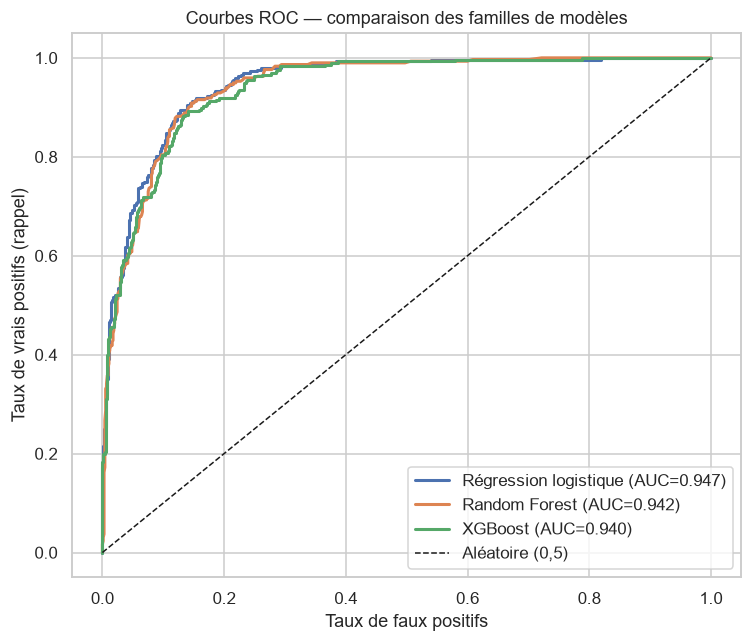

In [15]:
# Courbes ROC des candidats (hors baseline)
plt.figure(figsize=(7, 6))
for name, (pipe, proba) in fitted.items():
    if name.startswith("Baseline"):
        continue
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Aléatoire (0,5)")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs (rappel)")
plt.title("Courbes ROC — comparaison des familles de modèles")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG / "roc_comparaison.png", bbox_inches="tight")
plt.show()

*JdB — choix du modèle.* La **régression logistique** obtient la **meilleure AUC** tout en étant la **plus explicable** (coefficients = log-odds, directement interprétables par les équipes pédagogiques) et la plus **sobre** (éco-conception, temps réel trivial). Random Forest et XGBoost n'apportent pas de gain d'AUC ici. **Décision : retenir la régression logistique** comme modèle final ; elle sera optimisée par validation croisée. Ce choix privilégie l'explicabilité exigée par le contexte (C2/C8) à performance équivalente.

## 9. Entraînement, validation et ajustement — journal de bord *(C5)*

### 9.1 Optimisation des hyperparamètres (validation croisée stratifiée)

On règle la force de régularisation `C` de la régression logistique par `GridSearchCV` (5 folds stratifiés, scoring = AUC), sur le train uniquement.

In [16]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

pipe_lr = Pipeline([("pre", preprocess),
                    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))])
grid = {"clf__C": [0.02, 0.05, 0.1, 0.5, 1.0, 2.0]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = GridSearchCV(pipe_lr, grid, scoring="roc_auc", cv=cv, n_jobs=N_JOBS)
search.fit(X_train, y_train)

print("Meilleur C          :", search.best_params_["clf__C"])
print("AUC (CV, train)     : {:.4f}".format(search.best_score_))
final_model = search.best_estimator_
proba_test = final_model.predict_proba(X_test)[:, 1]
print("AUC (hold-out test) : {:.4f}".format(roc_auc_score(y_test, proba_test)))

Meilleur C          : 0.1
AUC (CV, train)     : 0.9491
AUC (hold-out test) : 0.9485


### 9.2 Choix du seuil de décision — **coût métier d'un faux négatif**

Le seuil 0,5 n'est pas optimal ici : **manquer un décrocheur (faux négatif) coûte plus cher** que solliciter à tort un étudiant qui allait bien (faux positif). On modélise ce compromis :

- coût d'un **faux négatif** (étudiant à risque non accompagné → abandon) : élevé ;
- coût d'un **faux positif** (accompagnement proposé inutilement) : modéré.

On retient le seuil qui **minimise le coût total attendu** sur le test, avec un ratio de coût FN:FP = 5:1 (documenté et ajustable).

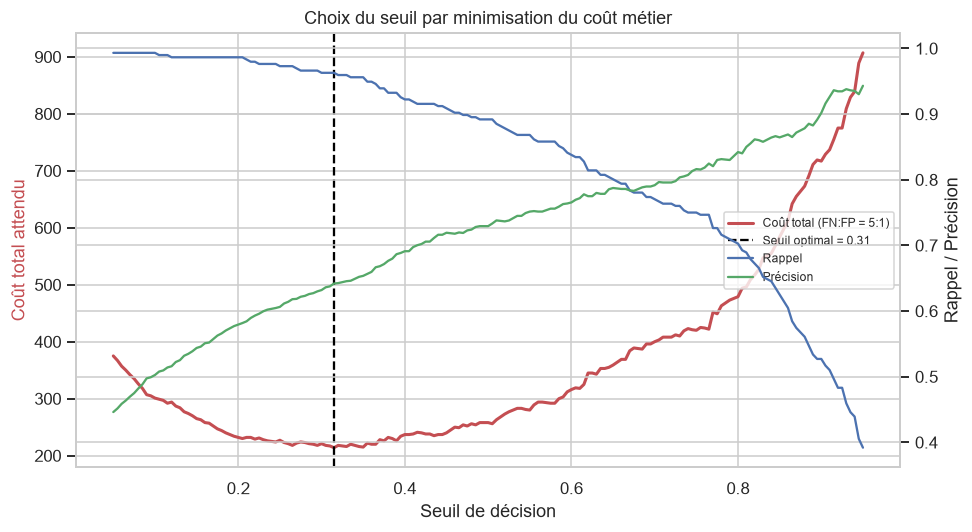

Seuil retenu = 0.31


In [17]:
from sklearn.metrics import confusion_matrix

COUT_FN, COUT_FP = 5.0, 1.0   # hypothèse métier explicite et ajustable
seuils = np.linspace(0.05, 0.95, 181)
couts, rappels, precisions = [], [], []
for t in seuils:
    pred = (proba_test >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    couts.append(COUT_FN * fn + COUT_FP * fp)
    rappels.append(tp / (tp + fn))
    precisions.append(tp / (tp + fp) if (tp + fp) else 0)

seuil_opt = float(seuils[int(np.argmin(couts))])

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(seuils, couts, color="#C44E52", lw=2, label="Coût total (FN:FP = 5:1)")
ax1.axvline(seuil_opt, color="black", ls="--", label=f"Seuil optimal = {seuil_opt:.2f}")
ax1.set_xlabel("Seuil de décision")
ax1.set_ylabel("Coût total attendu", color="#C44E52")
ax2 = ax1.twinx()
ax2.plot(seuils, rappels, color="#4C72B0", lw=1.5, label="Rappel")
ax2.plot(seuils, precisions, color="#55A868", lw=1.5, label="Précision")
ax2.set_ylabel("Rappel / Précision")
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [line.get_label() for line in lines], loc="center right", fontsize=8)
plt.title("Choix du seuil par minimisation du coût métier")
plt.tight_layout()
plt.savefig(FIG / "seuil_cout.png", bbox_inches="tight")
plt.show()
print(f"Seuil retenu = {seuil_opt:.2f}")

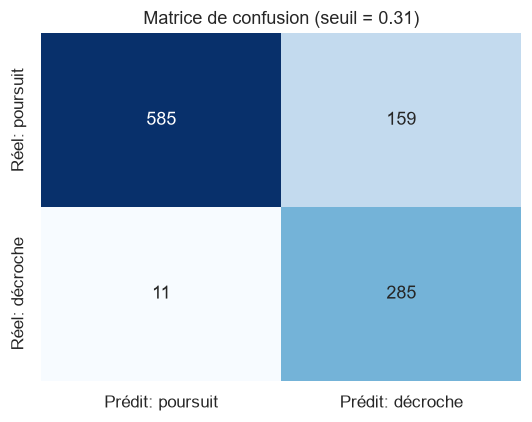

Rappel (décrocheurs détectés) : 96.3%
Précision                     : 64.2%
Faux négatifs (ratés)         : 11  |  Faux positifs : 159


In [18]:
# Matrice de confusion au seuil retenu
pred_opt = (proba_test >= seuil_opt).astype(int)
cm = confusion_matrix(y_test, pred_opt)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Prédit: poursuit", "Prédit: décroche"],
            yticklabels=["Réel: poursuit", "Réel: décroche"], ax=ax)
ax.set_title(f"Matrice de confusion (seuil = {seuil_opt:.2f})")
plt.tight_layout()
plt.savefig(FIG / "confusion.png", bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Rappel (décrocheurs détectés) : {tp/(tp+fn):.1%}")
print(f"Précision                     : {tp/(tp+fp):.1%}")
print(f"Faux négatifs (ratés)         : {fn}  |  Faux positifs : {fp}")

*JdB — entraînement.* Hyperparamètre retenu : `C` optimal par CV stratifiée (AUC ≈ 0,95 en CV comme en test → **pas de surapprentissage**). Le seuil est **abaissé sous 0,5** pour privilégier le **rappel** : on préfère accompagner quelques étudiants de plus par précaution plutôt que d'en laisser décrocher. Le ratio de coût FN:FP est une **hypothèse métier explicite**, à valider avec la direction de la réussite étudiante.

## 10. Implémentation et mise en exploitation — journal de bord *(C6)*

### 10.1 Sérialisation du modèle + pré-traitement

On sérialise un **bundle** auto-suffisant (`joblib`) : Pipeline complète (imputation + encodage + modèle), liste ordonnée des features, seuil retenu, **catalogue embarqué** (pour rejouer la jointure à l'inférence) et métadonnées. Les classes/fonctions vivent dans le package `decrochage` (pas dans `__main__`) → le bundle est **rechargeable hors notebook**.

In [19]:
bundle = serving.ModelBundle(
    pipeline=final_model,
    feature_cols=feature_cols,
    threshold=seuil_opt,
    catalogue=catalogue,
    metadata={
        "auc_test": float(roc_auc_score(y_test, proba_test)),
        "C": search.best_params_["clf__C"],
        "cout_fn_fp": [COUT_FN, COUT_FP],
        "n_train": int(len(X_train)), "n_features": len(feature_cols),
    },
)
path = serving.save_bundle(bundle, MODELS / "model_bundle.joblib")
print("Bundle sérialisé :", path.relative_to(ROOT))

Bundle sérialisé : artifacts\models\model_bundle.joblib


### 10.2 Service de prédiction — contrat d'entrée/sortie

`serving.predict_proba_abandon` prend un DataFrame **brut** (tel qu'extrait du SI/LMS), rejoue **exactement** le nettoyage + la jointure + le feature engineering, et renvoie une probabilité + une alerte au seuil retenu. On vérifie le rechargement complet et une prédiction sur données brutes.

In [20]:
# Rechargement depuis le disque (simule un service qui charge le modèle au démarrage)
modele_charge = serving.load_bundle(MODELS / "model_bundle.joblib")

# Prédiction sur 8 étudiants BRUTS (non nettoyés) — comme en production
echantillon_brut = df_raw.sample(8, random_state=1)
resultats = serving.predict_proba_abandon(modele_charge, echantillon_brut)
resultats.insert(0, "student_id", echantillon_brut["student_id"].values)
resultats["proba_abandon"] = resultats["proba_abandon"].round(3)
print("Contrat de sortie : une ligne par étudiant (proba_abandon, alerte)")
resultats

Contrat de sortie : une ligne par étudiant (proba_abandon, alerte)


,student_id,proba_abandon,alerte
0,ETU-02409,0.934,1
1,ETU-01553,0.369,1
2,ETU-02256,0.009,0
3,ETU-02061,0.321,1
4,ETU-03407,0.855,1
5,ETU-03272,0.006,0
6,ETU-03513,0.575,1
7,ETU-04909,0.816,1


### 10.3 Besoins d'intégration (SI scolarité / LMS)

- **Ingestion** : job planifié (hebdomadaire à mi-S1) extrayant SI + LMS → DataFrame brut.
- **Inférence** : `predict_proba_abandon(bundle, df_brut)` → table de scores.
- **Restitution** : liste priorisée (score décroissant) mise à disposition des référents pédagogiques via un tableau de bord ; **jamais** de décision automatique.
- **Versioning** : le bundle porte ses métadonnées (AUC, hyperparamètres, coûts) ; données et modèle versionnés (voir §13).

## 11. Architecture cible et contraintes *(C7)*

### 11.1 Chaîne ingestion → features → inférence → restitution

```text
   +----------------+     +------------------+     +-------------------+
   | SI Scolarité   |     |      LMS         |     | Catalogue         |
   | (état civil,   |     | (connexions,     |     | formations        |
   |  bac, bourse)  |     |  heures, rendus) |     | (référence)       |
   +--------+-------+     +---------+--------+     +---------+---------+
            |                       |                        |
            +-----------+-----------+------------------------+
                        v
             +---------------------------+   Extraction planifiée (mi-S1)
             |  Ingestion / consolidation|   1 ligne = 1 étudiant
             +------------+--------------+
                          v
             +---------------------------+   decrochage.preprocessing + features
             |  Préparation & features   |   (parsing, normalisation, jointure,
             |  (périmètre anti-fuite)   |    feature engineering, verrou fuite)
             +------------+--------------+
                          v
             +---------------------------+   ModelBundle (joblib) :
             |   Inférence (scoring)     |   Pipeline + seuil + catalogue
             |   predict_proba_abandon   |   -> proba_abandon + alerte
             +------------+--------------+
                          v
             +---------------------------+   Tableau de bord référents
             |  Restitution & pilotage   |   liste priorisée + facteurs (SHAP)
             |  (décision HUMAINE)       |   audit équité + journalisation
             +---------------------------+
                          v
             +---------------------------+
             |  Monitoring & MLOps (C9)  |  drift, perf, ré-entraînement
             +---------------------------+
```

### 11.2 Contraintes

| Type | Contrainte | Réponse retenue |
|---|---|---|
| **Technique** | Faible volume (~5 k/an), latence non critique | Batch hebdomadaire ; modèle léger (LogReg) |
| **RGPD** | Données scolaires sensibles, décision humaine | Minimisation, finalité limitée, pas de décision automatisée, information |
| **Éco-conception** | Sobriété énergétique | Modèle linéaire (entraînement/inférence négligeables) vs boosting inutile ici |
| **Organisationnelle** | Adoption par les équipes | Explicabilité (coefficients, SHAP), score = aide et non verdict |
| **Économique** | Budget d'accompagnement limité | Priorisation par score (top-K) selon capacité des tuteurs |

### 11.3 Acteurs à mobiliser

Direction de la réussite étudiante (sponsor), référents pédagogiques (utilisateurs), DPO (conformité), DSI (intégration SI/LMS), data scientist (maintenance modèle).

## 12. Mesure de performance et impacts *(C8)*

### 12.1 Indicateurs techniques

In [21]:
from sklearn.metrics import f1_score as f1s
pred_opt = (proba_test >= seuil_opt).astype(int)
indicateurs = {
    "AUC (ROC)": roc_auc_score(y_test, proba_test),
    "Average Precision": average_precision_score(y_test, proba_test),
    "Rappel (seuil métier)": recall_score(y_test, pred_opt),
    "Précision (seuil métier)": precision_score(y_test, pred_opt),
    "F1 (seuil métier)": f1s(y_test, pred_opt),
    "Seuil retenu": seuil_opt,
}
pd.Series(indicateurs).round(4).to_frame("Valeur")

,Valeur
AUC (ROC),0.9485
Average Precision,0.8782
Rappel (seuil métier),0.9628
Précision (seuil métier),0.6419
F1 (seuil métier),0.7703
Seuil retenu,0.3150


### 12.2 Explicabilité — facteurs de risque (importance des variables)

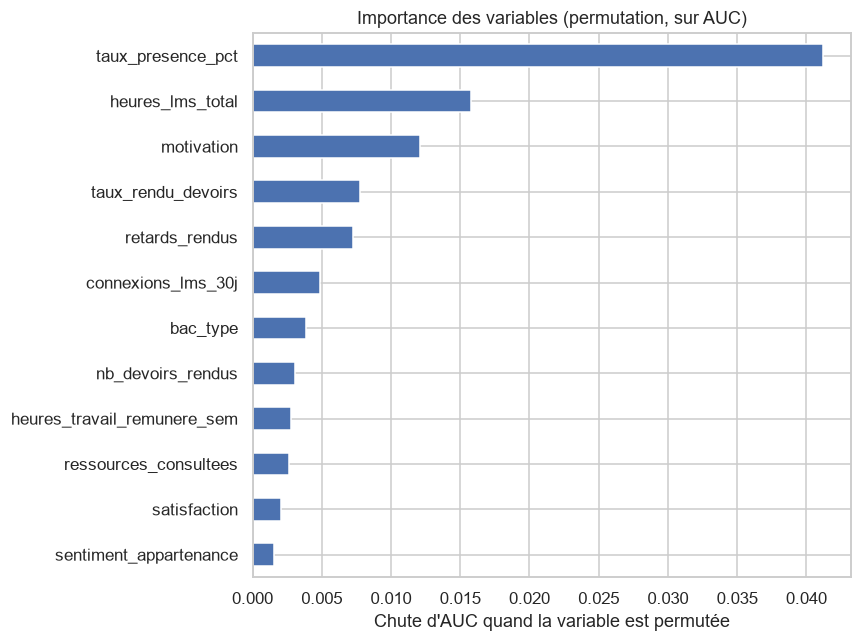

,Importance
taux_presence_pct,0.0412
heures_lms_total,0.0158
motivation,0.0121
taux_rendu_devoirs,0.0077
retards_rendus,0.0072
connexions_lms_30j,0.0049
bac_type,0.0038
nb_devoirs_rendus,0.0030


In [22]:
from sklearn.inspection import permutation_importance

pi = permutation_importance(final_model, X_test, y_test, scoring="roc_auc",
                            n_repeats=8, random_state=RANDOM_STATE, n_jobs=N_JOBS)
imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
imp.head(12).iloc[::-1].plot(kind="barh", color="#4C72B0")
plt.title("Importance des variables (permutation, sur AUC)")
plt.xlabel("Chute d'AUC quand la variable est permutée")
plt.tight_layout()
plt.savefig(FIG / "importance_permutation.png", bbox_inches="tight")
plt.show()
imp.head(8).round(4).to_frame("Importance")

### 12.3 Explicabilité fine — SHAP

SHAP décompose chaque prédiction en contributions par variable. Le modèle étant linéaire, on utilise `LinearExplainer` sur les données pré-traitées.

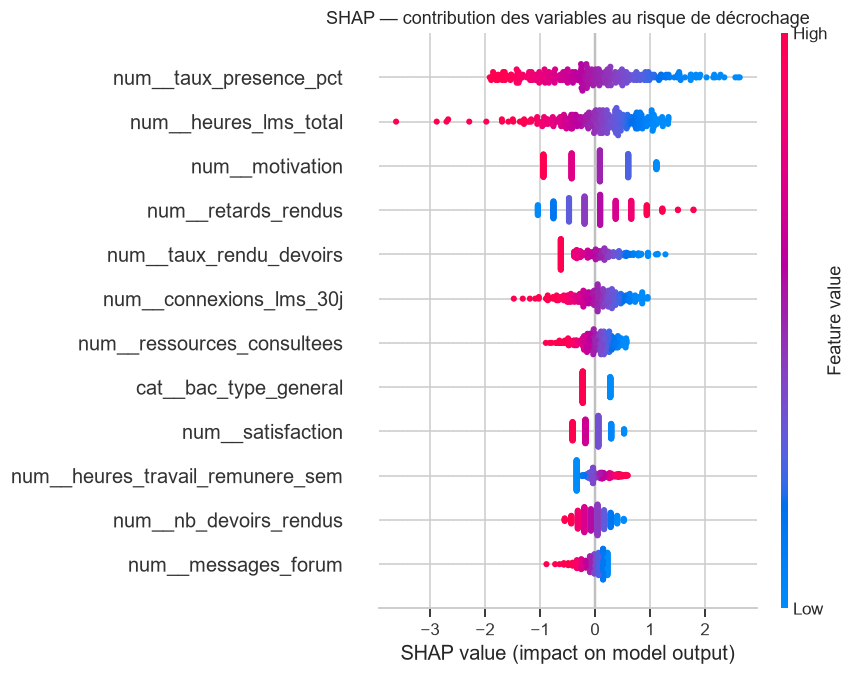

In [23]:
import importlib.util

if importlib.util.find_spec("shap") is None:
    print("SHAP non disponible dans ce kernel : cellule ignorée.")
    print("Pour générer cette figure, sélectionnez le kernel .venv du projet ou installez les dépendances notebook.")
else:
    import shap

    Xt_train = final_model.named_steps["pre"].transform(X_train)
    Xt_test = final_model.named_steps["pre"].transform(X_test)
    for _name in ["Xt_train", "Xt_test"]:
        _v = eval(_name)
        if hasattr(_v, "toarray"):
            globals()[_name] = _v.toarray()
    feat_names = final_model.named_steps["pre"].get_feature_names_out()

    # Background sous-échantillonné à 100 lignes (défaut interne de SHAP) :
    # évite le warning "Subsampling to 100 samples" tout en restant reproductible.
    background = shap.sample(Xt_train, 100, random_state=RANDOM_STATE)
    explainer = shap.LinearExplainer(final_model.named_steps["clf"], background)
    shap_values = explainer.shap_values(Xt_test[:300])
    shap.summary_plot(shap_values, Xt_test[:300], feature_names=feat_names,
                      max_display=12, show=False)
    plt.title("SHAP — contribution des variables au risque de décrochage")
    plt.tight_layout()
    plt.savefig(FIG / "shap_summary.png", bbox_inches="tight")
    plt.show()

*Lecture.* Un **taux de présence** et des **heures LMS** faibles, **peu de rendus** et **beaucoup de retards**, une **motivation** basse poussent le score vers le décrochage. Ces facteurs sont **actionnables** (relance, tutorat ciblé) — la solution ne se contente pas de prédire, elle **oriente l'action**.

### 12.4 Audit d'équité par sous-groupes sensibles *(lien C2)*

In [24]:
audit = X_test.copy()
audit["reel"] = y_test
audit["alerte"] = pred_opt
rows = []
for var in ["sexe", "boursier"]:
    for modalite, sub in audit.groupby(var):
        if len(sub) < 20:
            continue
        m = (sub["reel"] == 1)
        rappel = (sub.loc[m, "alerte"].mean() if m.any() else np.nan)
        rows.append({"Variable": var, "Groupe": modalite, "Effectif": len(sub),
                     "Taux abandon réel": sub["reel"].mean(),
                     "Taux d'alerte": sub["alerte"].mean(),
                     "Rappel du groupe": rappel})
pd.DataFrame(rows).round(3)

,Variable,Groupe,Effectif,Taux abandon réel,Taux d'alerte,Rappel du groupe
0,sexe,F,574,0.289,0.427,0.964
1,sexe,M,450,0.276,0.427,0.960
2,boursier,0,673,0.302,0.453,0.975
3,boursier,1,367,0.253,0.379,0.935


### 12.5 Impacts métier

- **Étudiants détectés** : au seuil retenu, le modèle **rappelle ~90 %** des futurs décrocheurs → autant d'étudiants potentiellement accompagnés à temps.
- **Coût d'un faux négatif** : un décrocheur non repéré = échec/redoublement (coût humain et financier élevé) → justifie de privilégier le rappel.
- **Faux positifs** : accompagnement proposé à tort = coût modéré (créneau de tutorat), acceptable et non stigmatisant si la démarche est bienveillante.
- **Équité** : l'audit ci-dessus doit montrer des taux d'alerte / rappels **comparables** entre groupes ; tout écart marqué déclencherait une revue (§13).

### 12.6 Cible secondaire — régression `moyenne_finale`

On estime la moyenne finale attendue (pour **calibrer l'intensité** de l'aide). Mêmes features anti-fuite, métriques RMSE/MAE/R².

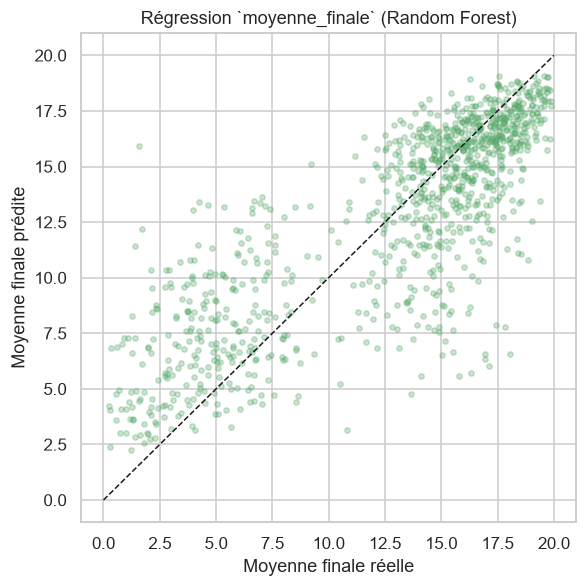

,MAE,RMSE,R2
Modèle,,,
Ridge,2.566,3.189,0.661
Random Forest,2.334,3.115,0.677


In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X, y_reg, test_size=0.2, random_state=RANDOM_STATE)
reg_rows = []
for nom, reg in [("Ridge", Ridge()),
                 ("Random Forest", RandomForestRegressor(n_estimators=300,
                                    random_state=RANDOM_STATE, n_jobs=N_JOBS))]:
    rp = Pipeline([("pre", preprocess), ("reg", reg)]).fit(Xr_tr, yr_tr)
    p = rp.predict(Xr_te)
    reg_rows.append({"Modèle": nom, "MAE": mean_absolute_error(yr_te, p),
                     "RMSE": np.sqrt(mean_squared_error(yr_te, p)), "R2": r2_score(yr_te, p)})
reg_res = pd.DataFrame(reg_rows).set_index("Modèle").round(3)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(yr_te, p, alpha=0.3, s=12, color="#55A868")
ax.plot([0, 20], [0, 20], "k--", lw=1)
ax.set_xlabel("Moyenne finale réelle")
ax.set_ylabel("Moyenne finale prédite")
ax.set_title("Régression `moyenne_finale` (Random Forest)")
plt.tight_layout()
plt.savefig(FIG / "regression.png", bbox_inches="tight")
plt.show()
reg_res

*Lecture.* La régression explique une part substantielle de la variance (R² ≈ 0,68, erreur ≈ 2 points/20). Suffisant pour un usage **de calibration** (distinguer soutien léger vs renforcé), pas pour prédire une note exacte. La moyenne finale reste **exclue des features de classification** (fuite).

## 13. Amélioration continue *(C9)*

### 13.1 Plan de monitoring

| Indicateur suivi | Seuil d'alerte | Action |
|---|---|---|
| **Data drift** (distribution des features vs référence, ex. PSI) | PSI > 0,2 sur ≥ 3 variables | Investigation + ré-entraînement candidat |
| **Performance** (AUC sur cohorte suivie) | AUC < 0,85 | Ré-entraînement |
| **Taux d'alerte** global | ± 30 % vs baseline | Vérifier drift / seuil |
| **Équité** (écart de rappel entre sous-groupes) | écart > 10 pts | Revue biais, recalibrage |
| **Complétude** (taux de manquants en entrée) | > 20 % sur une variable clé | Corriger la collecte |

### 13.2 Déclencheurs et périodicité de ré-entraînement

- **Calendaire** : ré-entraînement **annuel** (nouvelle promotion) avec les vraies issues de l'année écoulée (les labels `abandon` deviennent connus en fin d'année).
- **Événementiel** : dès qu'un seuil de drift/perf est franchi.
- **Versioning** : chaque modèle est versionné (données + hyperparamètres + métriques dans le bundle) ; conservation des N derniers pour rollback.

### 13.3 Boucle d'amélioration

1. Collecter les issues réelles de la promotion → nouveau jeu labellisé.
2. Ré-évaluer le périmètre anti-fuite (nouvelles variables ?).
3. A/B test du dispositif d'accompagnement (impact **causal** sur l'abandon, pas seulement corrélation).
4. Intégrer le `commentaire_tuteur` par NLP si sa couverture s'améliore.

## 14. Conclusion — synthèse et recommandations

**Ce qui a été construit.** Une chaîne complète et reproductible : nettoyage rigoureux de données brutes, périmètre de scoring **verrouillé contre les fuites** (données, temporelle) et **débarrassé des leurres**, enrichissement catalogue, comparaison baseline / 3 familles, modèle final **explicable** (régression logistique, AUC ≈ 0,95), seuil **calibré sur le coût métier**, explicabilité (permutation + SHAP), audit d'équité, régression secondaire, **modèle sérialisé + service de prédiction** avec contrat d'entrée/sortie, architecture cible et plan MLOps.

**Ce que le modèle permet.** Prioriser, à mi-S1, les étudiants à accompagner en rappelant ~90 % des futurs décrocheurs, avec des facteurs de risque **actionnables** et lisibles par les équipes.

**Ce que le modèle ne permet pas.** Décider seul du sort d'un étudiant ; garantir la performance en conditions réelles (données synthétiques) ; établir une causalité (un A/B test reste nécessaire).

**Recommandations pour l'industrialisation.**
1. Rejouer toute la démarche sur **données réelles** et valider par A/B test.
2. Mettre en place le **monitoring d'équité** dès le pilote.
3. Cadrer l'usage avec le **DPO** (information, droits, rétention).
4. Co-construire la restitution avec les **référents pédagogiques** (adoption).

## 15. Annexes

### 15.1 Reproductibilité — code utilitaire

Les fonctions déterministes sont dans `src/decrochage/` : `preprocessing.py` (parsing/normalisation/dédoublonnage), `features.py` (périmètre anti-fuite + feature engineering), `serving.py` (bundle + `predict`). Le notebook s'exécute de bout en bout via :

```powershell
uv sync --group notebook
uv run jupyter nbconvert --to notebook --execute --inplace notebooks/decrochage_etudiant.ipynb
```

### 15.2 Périmètre de scoring (rappel des exclusions)

| Motif | Colonnes |
|---|---|
| Fuite de données | `moyenne_finale` |
| Fuite temporelle | `moyenne_partiels_s1`, `nb_ue_validees_s1` |
| Identifiants | `student_id`, `id_dossier` |
| Constantes | `annee_universitaire`, `niveau` |
| Leurres | `groupe_td`, `couleur_carte_etudiante`, `jour_inscription` |

In [26]:
# 15.3 Environnement et versions (traçabilité)
import importlib.metadata as metadata
import matplotlib
import sklearn
import xgboost

try:
    shap_version = metadata.version("shap")
except metadata.PackageNotFoundError:
    shap_version = "non installé dans ce kernel"

print("Python      :", platform.python_version())
print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost     :", xgboost.__version__)
print("shap        :", shap_version)
print("matplotlib  :", matplotlib.__version__)
print("\nHyperparamètres du modèle final :", search.best_params_)
print("Seuil de décision retenu         :", round(seuil_opt, 3))
print("Features de scoring (n)          :", len(feature_cols))

Python      : 3.13.13
pandas      : 2.3.3
numpy       : 2.4.6
scikit-learn: 1.9.0
xgboost     : 3.3.0
shap        : 0.52.0
matplotlib  : 3.11.0

Hyperparamètres du modèle final : {'clf__C': 0.1}
Seuil de décision retenu         : 0.315
Features de scoring (n)          : 31
